
Loading Dataset...

Dataset Preview:

   CustomerID  Age  Gender   Device  Traffic_Source  Time_on_Website  \
0           1   23    Male   Mobile    Social Media                5   
1           2   35  Female  Desktop   Search Engine               12   
2           3   29    Male   Tablet    Social Media                8   
3           4   41  Female   Mobile  Email Campaign               15   
4           5   22  Female  Desktop          Direct                4   

   Pages_Visited  Ad_Clicks  Previous_Purchases  Purchased  
0              3          1                   0          0  
1              8          3                   2          1  
2              5          2                   1          0  
3             10          4                   3          1  
4              2          0                   0          0  

Dataset Shape: (15, 10)

Dropping CustomerID column...

Encoding Categorical Features...

Encoded Dataset Preview:

   Age  Gender  Device  Traffic_Source  Time_

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


Best Parameters: {'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 50}

Making Predictions on Test Data...

Predictions:
 [0 1 0]

Model Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         1

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



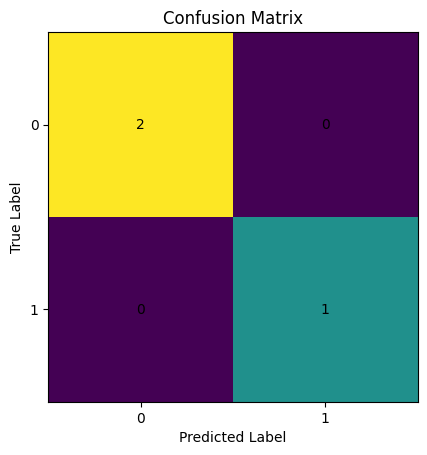

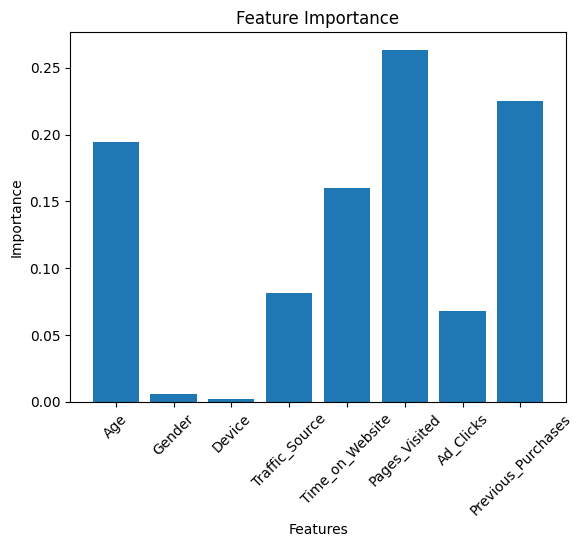


Predicting New Customer Purchase...

Customer is LIKELY to purchase.

Visualizing Purchase Distribution...


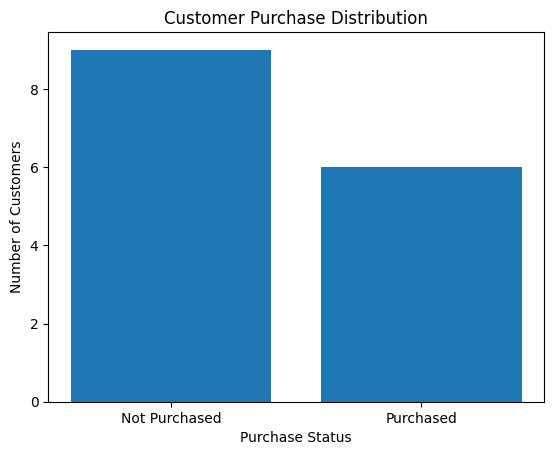


Visualizing Pages Visited vs Purchase...


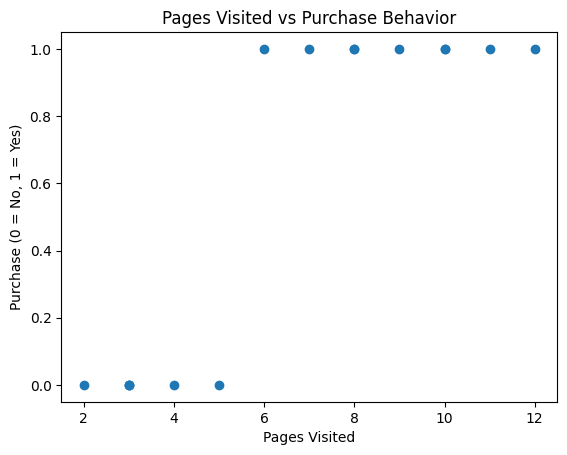


Visualizing Time on Website vs Purchase...


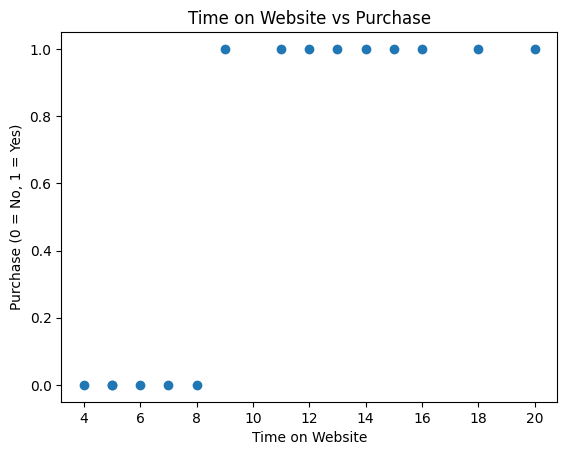

In [9]:
# Capstone Project 3
# Smart Marketing Prediction System (ML Pipeline Project)

# Scenario:
# A fast-growing e-commerce company called "ShopEasy" is facing
# inefficiencies in its marketing campaigns.

# Every day thousands of users visit the website, but many of them
# browse products without making a purchase. The marketing team
# spends a large amount of money on ads, promotional emails, and
# discounts, but they are unable to identify which customers are
# actually likely to buy something.

# Current Problems:
# 1. Many customers browse products but never complete a purchase.
# 2. Marketing budget is wasted targeting users who will not buy.
# 3. The company cannot accurately estimate purchase probability.

# Business Objective:
# The data science team has been asked to build a Machine Learning
# system that predicts whether a customer will purchase a product
# during a browsing session.

# If the system predicts HIGH purchase probability:
# - Show personalized product recommendations
# - Offer targeted discounts
# - Prioritize marketing campaigns

# If the system predicts LOW purchase probability:
# - Avoid spending marketing budget on that user
# - Reduce unnecessary promotional exposure

# Technical Challenge:
# The dataset contains both:
# - Numerical features (Age, Time_on_Website, Pages_Visited, etc.)
# - Categorical features (Gender, Device, Traffic_Source)

# Therefore, the data science team must design a complete
# Machine Learning Pipeline including:
# - Data preprocessing
# - Encoding categorical features
# - Feature scaling
# - Model training
# - Prediction of purchase probability

# The final system will help the company optimize marketing
# spending and increase conversion rates.

# Capstone Project 3
# Smart Marketing Prediction System {tech stack and there usage }

# Python
# Python is used as the primary programming language because
# it provides powerful libraries for data analysis, machine
# learning, and data visualization.

# Pandas
# Pandas is used for data manipulation and analysis.
# It helps in loading datasets, cleaning data, selecting
# columns, and preparing the dataset for machine learning.

# Matplotlib
# Matplotlib is used for data visualization.
# In this project it is used to plot graphs such as:
# - Confusion Matrix
# - Feature Importance Graph

# Scikit-learn (sklearn)
# Scikit-learn is a machine learning library used to build
# and evaluate machine learning models.

# train_test_split
# This function is used to split the dataset into
# training data and testing data.

# LabelEncoder
# LabelEncoder converts categorical values into numerical values.

# RandomForestClassifier
# Random Forest is a supervised machine learning algorithm
# that combines multiple decision trees.

# Pipeline
# Pipeline is used to automate preprocessing and model training
# steps so that the workflow becomes organized and reproducible.

# GridSearchCV
# GridSearchCV is used for hyperparameter tuning to find the
# best parameters for the machine learning model.

# accuracy_score
# Measures how many predictions made by the model are correct.

# classification_report
# Provides precision, recall and F1-score metrics.

# confusion_matrix
# Shows comparison between actual and predicted values.


import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV



# Load Dataset

print("\nLoading Dataset...\n")

data = pd.read_excel("DatasetCapstoneProject3.xlsx")

print("Dataset Preview:\n")
print(data.head())

print("\nDataset Shape:", data.shape)


# Drop CustomerID

print("\nDropping CustomerID column...")

data = data.drop("CustomerID", axis=1)


# Encode Categorical Columns

print("\nEncoding Categorical Features...")

le_gender = LabelEncoder()
le_device = LabelEncoder()
le_traffic = LabelEncoder()

data["Gender"] = le_gender.fit_transform(data["Gender"])
data["Device"] = le_device.fit_transform(data["Device"])
data["Traffic_Source"] = le_traffic.fit_transform(data["Traffic_Source"])

print("\nEncoded Dataset Preview:\n")
print(data.head())


# Define Features and Target

print("\nSeparating Features and Target...")

X = data.drop("Purchased", axis=1)
y = data["Purchased"]

print("\nFeatures:\n", X.head())
print("\nTarget:\n", y.head())


# Train Test Split

print("\nSplitting Data (80% Train / 20% Test)...")

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("\nTraining Data Size:", X_train.shape)
print("Testing Data Size:", X_test.shape)


# Machine Learning Pipeline

print("\nCreating Machine Learning Pipeline...")

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RandomForestClassifier(random_state=42))
])

pipeline.fit(X_train, y_train)

print("Pipeline Training Completed.")


# Hyperparameter Tuning

print("\nStarting Hyperparameter Tuning...")

param_grid = {
    "model__n_estimators":[50,100,200],
    "model__max_depth":[None,5,10],
    "model__min_samples_split":[2,5]
}

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="accuracy"
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)


# Predictions

print("\nMaking Predictions on Test Data...")

y_pred = grid_search.predict(X_test)

print("\nPredictions:\n", y_pred[:10])


# Model Evaluation

accuracy = accuracy_score(y_test, y_pred)

print("\nModel Accuracy:", accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


# Confusion Matrix Graph

cm = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks([0,1])
plt.yticks([0,1])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i,j], ha="center", va="center")

plt.show()


# Feature Importance Graph

best_model = grid_search.best_estimator_.named_steps["model"]

importances = best_model.feature_importances_
features = X.columns

plt.figure()
plt.bar(features, importances)

plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.xticks(rotation=45)

plt.show()


# Predict New Customer

print("\nPredicting New Customer Purchase...\n")

new_customer = pd.DataFrame({
    "Age":[30],
    "Gender":[1],
    "Device":[1],
    "Traffic_Source":[2],
    "Time_on_Website":[12],
    "Pages_Visited":[7],
    "Ad_Clicks":[2],
    "Previous_Purchases":[1]
})

prediction = grid_search.predict(new_customer)

if prediction[0] == 1:
    print("Customer is LIKELY to purchase.")
else:
    print("Customer is NOT likely to purchase.")



# Exploratory Data Analysis (EDA)


print("\nVisualizing Purchase Distribution...")

purchase_counts = data["Purchased"].value_counts()

plt.figure()
plt.bar(["Not Purchased","Purchased"], purchase_counts)

plt.title("Customer Purchase Distribution")
plt.xlabel("Purchase Status")
plt.ylabel("Number of Customers")

plt.show()

print("\nVisualizing Pages Visited vs Purchase...")

plt.figure()

plt.scatter(
    data["Pages_Visited"],
    data["Purchased"]
)

plt.title("Pages Visited vs Purchase Behavior")
plt.xlabel("Pages Visited")
plt.ylabel("Purchase (0 = No, 1 = Yes)")

plt.show()





print("\nVisualizing Time on Website vs Purchase...")

plt.figure()

plt.scatter(
    data["Time_on_Website"],
    data["Purchased"]
)

plt.title("Time on Website vs Purchase")
plt.xlabel("Time on Website")
plt.ylabel("Purchase (0 = No, 1 = Yes)")

plt.show()